In [33]:
from statsbombpy import sb
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az

/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [37]:
competitions = pd.DataFrame(sb.competitions())
top_comps = ['La Liga']
most_recent_seasons = ['2018/2019', '2017/2018', '2016/2017', '2015/2016', '2014/2015']
pairs = competitions[
    competitions['competition_name'].isin(top_comps) &
    competitions['season_name'].isin(most_recent_seasons)
][['competition_name', 'season_name', 'competition_id', 'season_id']].drop_duplicates().sort_values(by = 'competition_name')

print(pairs)



   competition_name season_name  competition_id  season_id
40          La Liga   2018/2019              11          4
41          La Liga   2017/2018              11          1
42          La Liga   2016/2017              11          2
43          La Liga   2015/2016              11         27
44          La Liga   2014/2015              11         26


/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [38]:
match_id_list = []

for comp_id, season_id in zip(pairs['competition_id'], pairs['season_id']):
    match_id_list = match_id_list + sb.matches(competition_id=comp_id, season_id=season_id)['match_id'].unique().tolist()

/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [76]:
all_shots = []
for match_id in match_id_list:
    events = sb.events(match_id=match_id)
    shots = events[(events['type']=='Shot') & (events['shot_type']=='Open Play')][['location','shot_outcome', 'shot_technique']]
    shots['goal'] = shots['shot_outcome'].apply(lambda x: 1 if x=='Goal' else 0)
    all_shots.append(shots[['location', 'goal', 'shot_technique']])
df_all_shots = pd.concat(all_shots)


/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/Users/shinsuke.adachi/miniconda3/envs/p

In [78]:
df_all_shots.goal.value_counts()

goal
0    10685
1     1349
Name: count, dtype: int64

In [79]:
df_all_shots['location_x'] = df_all_shots['location'].apply(lambda x: x[0])
df_all_shots['location_y'] = df_all_shots['location'].apply(lambda x: x[1])

In [83]:
df_all_shots.shot_technique.unique()

<StringArray>
[  'Half Volley',        'Normal',        'Volley', 'Overhead Kick',
           'Lob', 'Diving Header',      'Backheel']
Length: 7, dtype: str

<function matplotlib.pyplot.show(close=None, block=None)>

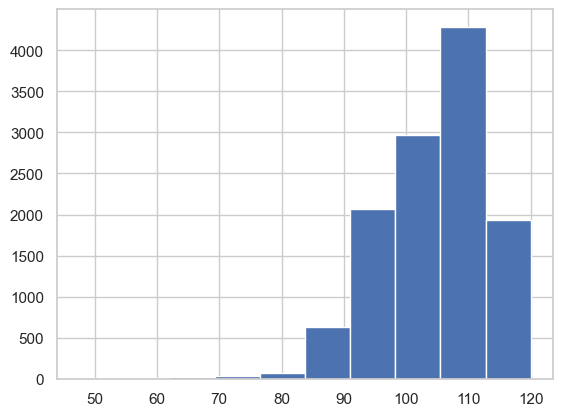

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df_all_shots['location_x'])
plt.title("")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

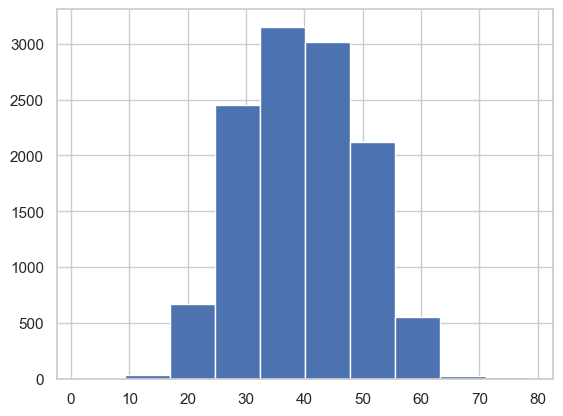

In [143]:
import matplotlib.pyplot as plt
plt.hist(df_all_shots['location_y'])
plt.show

In [ ]:
def engineer_features(df):
    df['distance'] = np.sqrt((120 - df['location_x'])**2 + (40 - df['location_y'])**2)
    
    d1 = np.sqrt((120 - df['location_x'])**2 + (36 - df['location_y'])**2)
    d2 = np.sqrt((120 - df['location_x'])**2 + (44 - df['location_y'])**2)
    w = 8 
    
    cos_theta = (d1**2 + d2**2 - w**2) / (2 * d1 * d2)
    df['angle'] = np.arccos(np.clip(cos_theta, -1, 1))

    df['shot_with_technique'] = df['shot_technique'].apply(lambda x: 1 if x!='Normal' else 0)
    
    return df
def scale_features(df):
    for col in ['distance', 'angle']:
        df[col] = (df[col] - df[col].mean()) / df[col].std()
    return df

In [179]:
df = df_all_shots.copy()

df = engineer_features(df)

## saving for later use
orig_dist_mean = df['distance'].mean()
orig_dist_std = df['distance'].std()
orig_angle_mean = df['angle'].mean()
orig_angle_std = df['angle'].std()

df = scale_features(df)

In [86]:
df.head()

,location,goal,shot_technique,location_x,location_y,distance,angle,shot_with_technique
3847,"[107.5, 29.7]",1,Half Volley,107.5,29.7,-0.263969,-0.237347,1
3848,"[99.4, 50.9]",0,Normal,99.4,50.9,0.578540,-0.539663,0
3849,"[112.8, 46.7]",0,Normal,112.8,46.7,-1.017912,0.619140,0
3850,"[113.1, 35.4]",0,Half Volley,113.1,35.4,-1.200701,1.307609,1
3851,"[112.4, 38.0]",0,Normal,112.4,38.0,-1.252136,1.738271,0


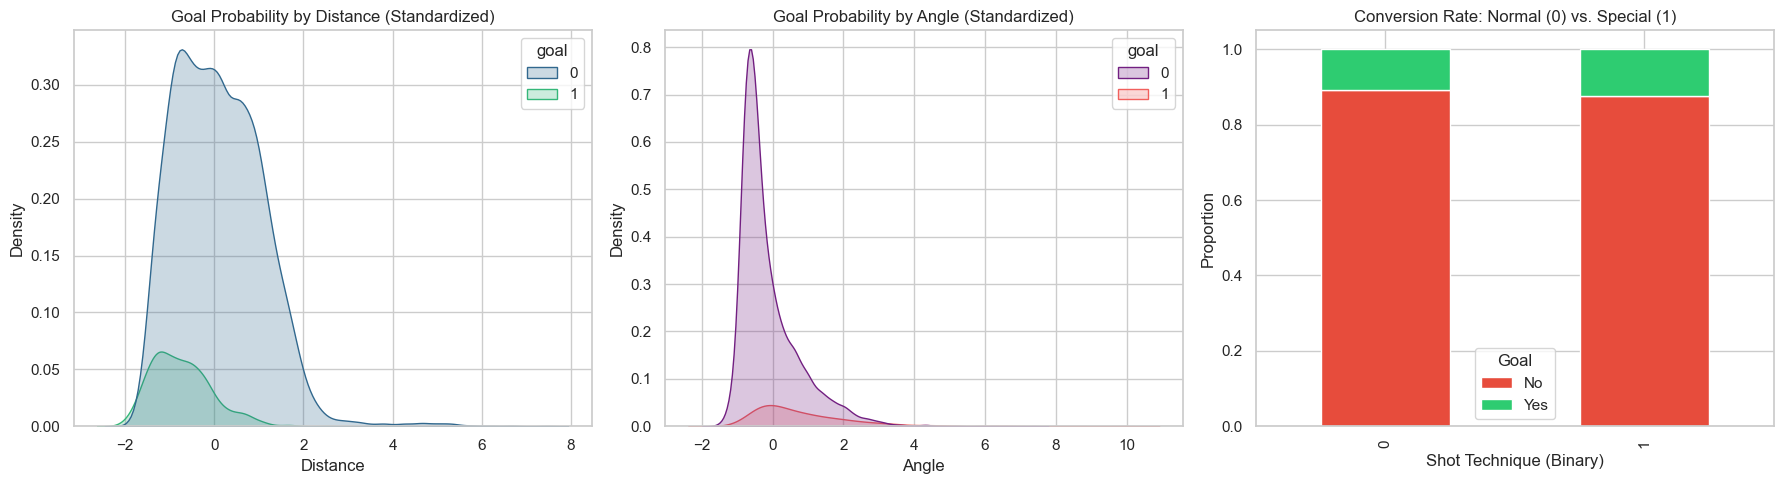

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_shot_features(df):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    sns.kdeplot(data=df, x='distance', hue='goal', fill=True, ax=axes[0], palette='viridis')
    axes[0].set_title('Goal Probability by Distance (Standardized)')
    axes[0].set_xlabel('Distance')
    
    sns.kdeplot(data=df, x='angle', hue='goal', fill=True, ax=axes[1], palette='magma')
    axes[1].set_title('Goal Probability by Angle (Standardized)')
    axes[1].set_xlabel('Angle')
    

    technique_counts = df.groupby(['shot_with_technique', 'goal']).size().unstack(fill_value=0)
    technique_props = technique_counts.div(technique_counts.sum(axis=1), axis=0)
    
    technique_props.plot(kind='bar', stacked=True, ax=axes[2], color=['#e74c3c', '#2ecc71'])
    axes[2].set_title('Conversion Rate: Normal (0) vs. Special (1)')
    axes[2].set_xlabel('Shot Technique (Binary)')
    axes[2].set_ylabel('Proportion')
    axes[2].legend(title='Goal', labels=['No', 'Yes'])
    
    plt.tight_layout()
    plt.show()


visualize_shot_features(df)

Text(0.5, 0, 'Distance')

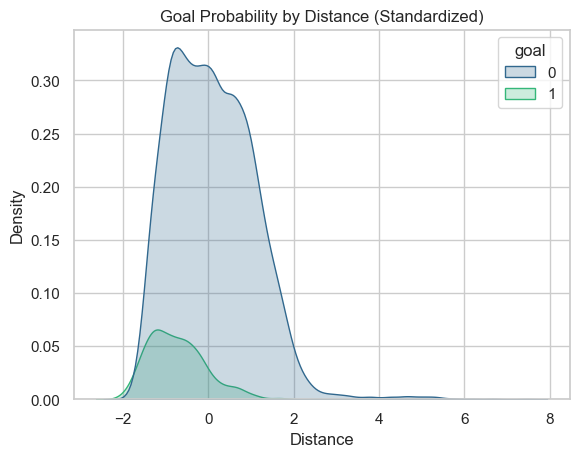

In [237]:
fig = sns.kdeplot(data=df, x='distance', hue='goal', fill=True, palette='viridis')
fig.set_title('Goal Probability by Distance (Standardized)')
fig.set_xlabel('Distance')

Text(0.5, 0, 'Angle')

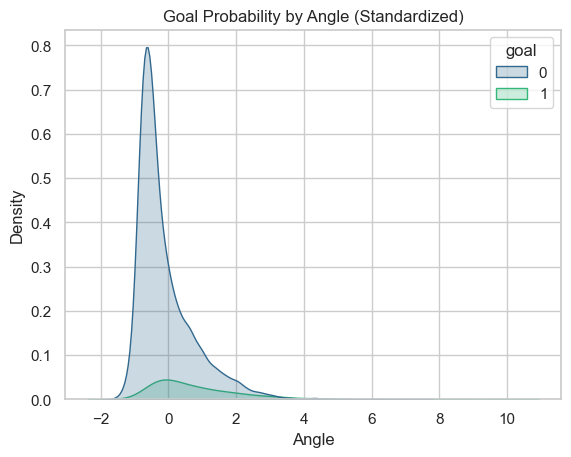

In [238]:
fig = sns.kdeplot(data=df, x='angle', hue='goal', fill=True, palette='viridis')
fig.set_title('Goal Probability by Angle (Standardized)')
fig.set_xlabel('Angle')

<Axes: title={'center': 'Shot Conversion: Normal vs Special Technique'}, xlabel='shot_with_technique'>

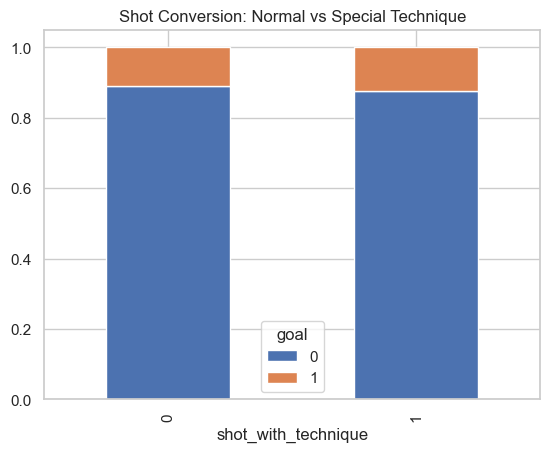

In [240]:
technique_counts = df.groupby(['shot_with_technique', 'goal']).size().unstack(fill_value=0)
technique_props = technique_counts.div(technique_counts.sum(axis=1), axis=0)
technique_props.plot(kind='bar', stacked=True, title = 'Shot Conversion: Normal vs Special Technique')

<function matplotlib.pyplot.show(close=None, block=None)>

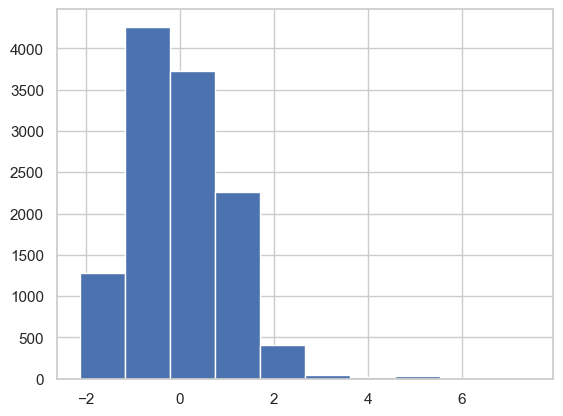

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['distance'])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

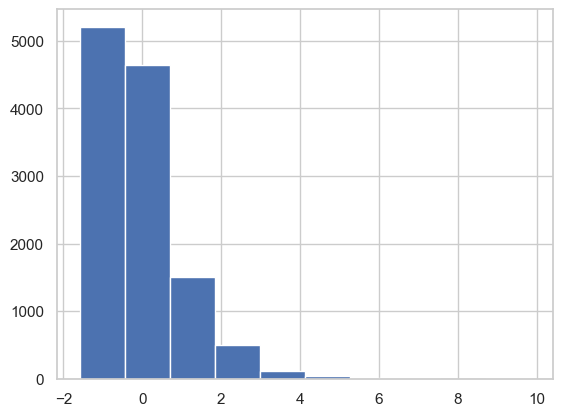

In [102]:
plt.hist(df['angle'])
plt.show

### Model

In [ ]:
coef_sigma = 2

X_dist = df['distance'].values
X_angle = df['angle'].values
y_obs = df['goal'].values 

with pm.Model() as m:
    dist_data = pm.Data('dist_data', X_dist)
    angle_data = pm.Data('angle_data', X_angle)

    y_data = pm.Data('y_data', y_obs)
    
    intercept = pm.Normal('intercept', mu=0, sigma=coef_sigma)
    beta_dist = pm.Normal('beta_dist', mu=0, sigma=coef_sigma)
    beta_angle = pm.Normal('beta_angle', mu=0, sigma=coef_sigma)
    
    p = pm.Deterministic('p', pm.math.sigmoid(intercept + 
                                              beta_dist * dist_data + 
                                              beta_angle * angle_data))

    likelihood = pm.Bernoulli('y', p=p, observed=y_data)
    
    trace = pm.sample(2000, tune=1000, target_accept=0.9, random_seed=100)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_dist, beta_angle]


/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 24 seconds.


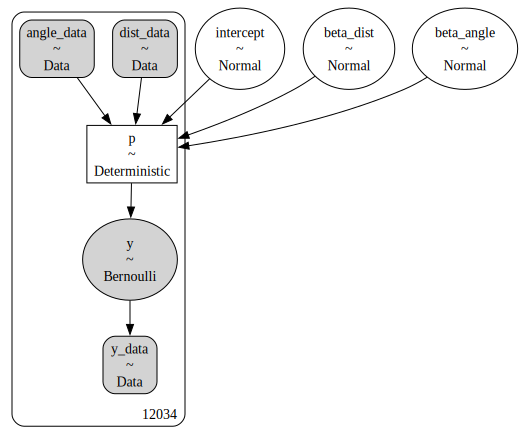

In [212]:
pm.model_to_graphviz(m)

In [213]:
az.summary(trace, hdi_prob=0.95, var_names=["intercept", "beta_dist", "beta_angle"])

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-2.455,0.040,-2.533,-2.376,0.001,0.000,3865.0,4205.0,1.0
beta_dist,-0.834,0.065,-0.967,-0.710,0.001,0.001,3052.0,3322.0,1.0
beta_angle,0.289,0.040,0.214,0.370,0.001,0.000,3530.0,4024.0,1.0


In [241]:
print(az.summary(trace, hdi_prob=0.95, var_names=["intercept", "beta_dist", "beta_angle"]).to_latex(escape=True, float_format="%.3f"))

\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & sd & hdi\_2.5\% & hdi\_97.5\% & mcse\_mean & mcse\_sd & ess\_bulk & ess\_tail & r\_hat \\
\midrule
intercept & -2.455 & 0.040 & -2.533 & -2.376 & 0.001 & 0.000 & 3865.000 & 4205.000 & 1.000 \\
beta\_dist & -0.834 & 0.065 & -0.967 & -0.710 & 0.001 & 0.001 & 3052.000 & 3322.000 & 1.000 \\
beta\_angle & 0.289 & 0.040 & 0.214 & 0.370 & 0.001 & 0.000 & 3530.000 & 4024.000 & 1.000 \\
\bottomrule
\end{tabular}



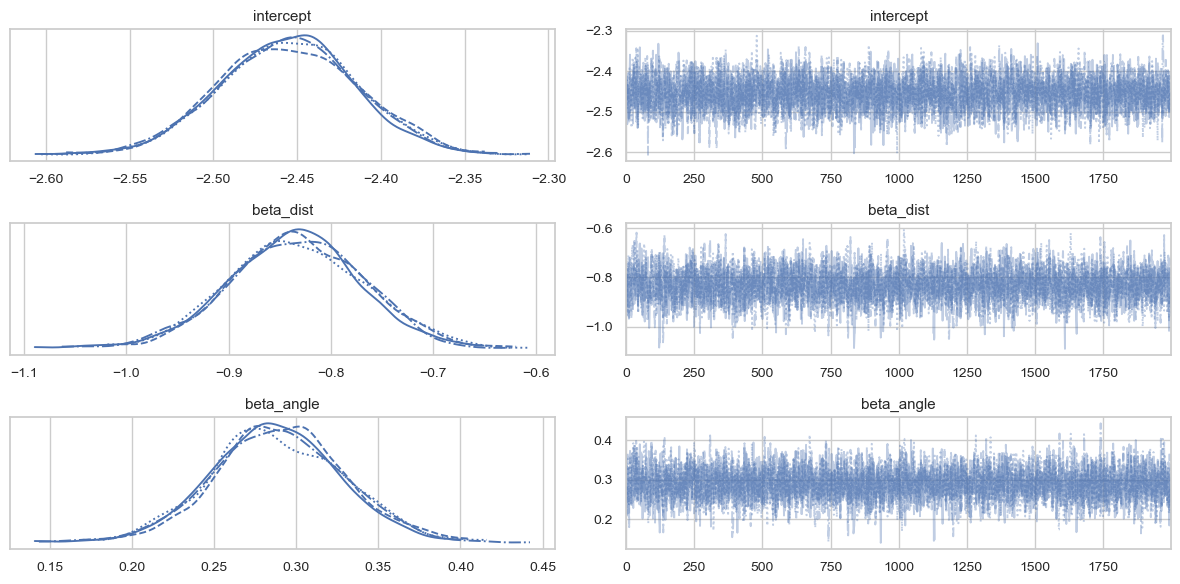

In [214]:
az.plot_trace(trace, var_names=["intercept", "beta_dist", "beta_angle"])
plt.tight_layout()
plt.show()

#### Model 2 with technique

In [ ]:
coef_sigma = 2

X_technique = df['shot_with_technique'].values

with pm.Model() as m2:
    dist_data = pm.Data('dist_data', X_dist)
    angle_data = pm.Data('angle_data', X_angle)
    technique_data = pm.Data('technique_data', X_technique)

    y_data = pm.Data('y_data', y_obs)
    
    intercept = pm.Normal('intercept', mu=0, sigma=coef_sigma)
    beta_dist = pm.Normal('beta_dist', mu=0, sigma=coef_sigma)
    beta_angle = pm.Normal('beta_angle', mu=0, sigma=coef_sigma)
    beta_technique = pm.Normal('beta_technique', mu=0, sigma=coef_sigma)
    
    p = pm.Deterministic('p', pm.math.sigmoid(intercept + 
                        beta_dist * dist_data + 
                        beta_angle * angle_data +
                        beta_technique * technique_data))
    
    likelihood = pm.Bernoulli('y', p=p, observed=y_data)
    
    trace2 = pm.sample(2000, tune=1000, target_accept=0.9, random_seed=100)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [intercept, beta_dist, beta_angle, beta_technique]


/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 34 seconds.


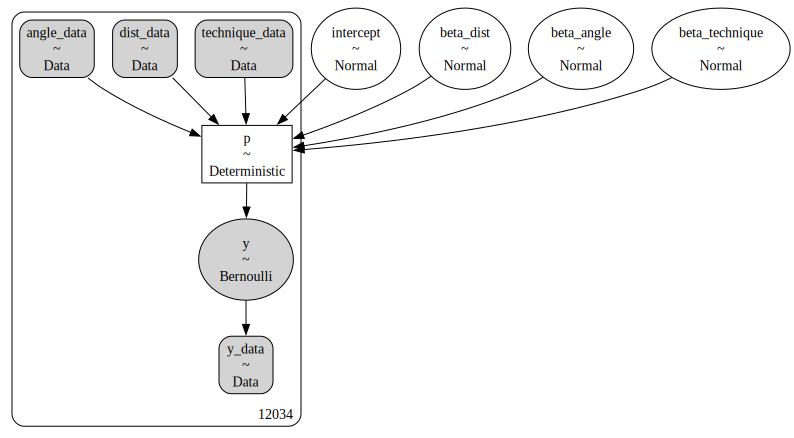

In [216]:
pm.model_to_graphviz(m2)

In [217]:
az.summary(trace2, hdi_prob=0.95, var_names=["intercept", "beta_dist", "beta_angle", "beta_technique"])

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-2.471,0.044,-2.560,-2.387,0.001,0.001,4248.0,4883.0,1.0
beta_dist,-0.830,0.065,-0.955,-0.699,0.001,0.001,3200.0,3985.0,1.0
beta_angle,0.291,0.040,0.215,0.369,0.001,0.000,3634.0,4296.0,1.0
beta_technique,0.058,0.069,-0.073,0.193,0.001,0.001,5379.0,4740.0,1.0


In [243]:
print(az.summary(trace2, hdi_prob=0.95, var_names=["intercept", "beta_dist", "beta_angle", "beta_technique"]).to_latex(escape=True, float_format="%.3f"))

\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & sd & hdi\_2.5\% & hdi\_97.5\% & mcse\_mean & mcse\_sd & ess\_bulk & ess\_tail & r\_hat \\
\midrule
intercept & -2.471 & 0.044 & -2.560 & -2.387 & 0.001 & 0.001 & 4248.000 & 4883.000 & 1.000 \\
beta\_dist & -0.830 & 0.065 & -0.955 & -0.699 & 0.001 & 0.001 & 3200.000 & 3985.000 & 1.000 \\
beta\_angle & 0.291 & 0.040 & 0.215 & 0.369 & 0.001 & 0.000 & 3634.000 & 4296.000 & 1.000 \\
beta\_technique & 0.058 & 0.069 & -0.073 & 0.193 & 0.001 & 0.001 & 5379.000 & 4740.000 & 1.000 \\
\bottomrule
\end{tabular}



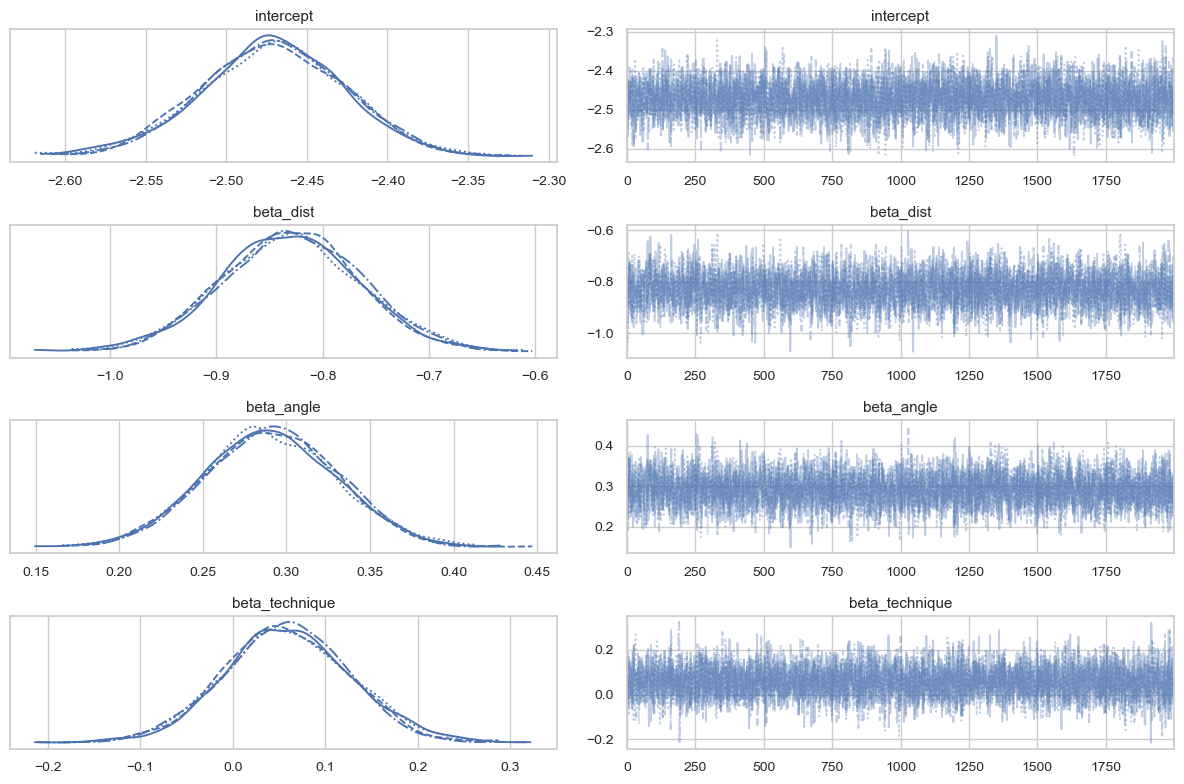

In [218]:
az.plot_trace(trace2, var_names=["intercept", "beta_dist", "beta_angle", "beta_technique"])
plt.tight_layout()
plt.show()

#### Prediction

In [189]:
## back post tap-in normal, penalty spot, Bale overhead, 45 degree left winger, Beckham freekick
location_x = [114, 108, 108, 98, 87]
location_y = [30, 40, 40, 24, 40]
shot_technique = ['Normal', 'Normal', 'Overhead kick', 'Normal', 'Normal']

df_new_data = pd.DataFrame({"location_x": location_x, "location_y": location_y, "shot_technique": shot_technique})
df_new_data = engineer_features(df_new_data)
df_new_data['distance'] = (df_new_data['distance'] - orig_dist_mean) / orig_dist_std
df_new_data['angle'] = (df_new_data['angle'] - orig_angle_mean) / orig_angle_std

In [190]:
df_new_data

,location_x,location_y,shot_technique,distance,angle,shot_with_technique
0,114,30,Normal,-0.801420,-0.256053,0
1,108,40,Normal,-0.761351,0.706138,0
2,108,40,Overhead kick,-0.761351,0.706138,1
3,98,24,Normal,1.040371,-0.775712,0
4,87,40,Normal,1.727389,-0.765545,0


In [ ]:
with m:
    pm.set_data({
            "dist_data": df_new_data['distance'].values, 
            "angle_data": df_new_data['angle'].values, 
            "y_data": [0,0,0,0,0] 
        })
    ppc = pm.sample_posterior_predictive(trace, var_names=['p'], predictions=True, random_seed=100)
    
    post_pred = pm.sample_posterior_predictive(
        trace, 
        var_names=['p'], 
        predictions=True, 
        random_seed=100
    )

Sampling: []


/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: []


/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [ ]:
az.summary(ppc.predictions, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p[0],0.135,0.006,0.123,0.148,0.0,0.0,4078.0,4033.0,1.0
p[1],0.166,0.004,0.158,0.174,0.0,0.0,7061.0,6309.0,1.0
p[2],0.166,0.004,0.158,0.174,0.0,0.0,7061.0,6309.0,1.0
p[3],0.028,0.002,0.024,0.032,0.0,0.0,3368.0,4115.0,1.0
p[4],0.016,0.002,0.012,0.020,0.0,0.0,3133.0,3609.0,1.0


In [245]:
print(az.summary(ppc.predictions, hdi_prob=0.95).to_latex(escape=True, float_format="%.3f"))

\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & sd & hdi\_2.5\% & hdi\_97.5\% & mcse\_mean & mcse\_sd & ess\_bulk & ess\_tail & r\_hat \\
\midrule
p[0] & 0.133 & 0.007 & 0.119 & 0.145 & 0.000 & 0.000 & 4688.000 & 5211.000 & 1.000 \\
p[1] & 0.163 & 0.005 & 0.154 & 0.174 & 0.000 & 0.000 & 6154.000 & 6243.000 & 1.000 \\
p[2] & 0.172 & 0.008 & 0.155 & 0.187 & 0.000 & 0.000 & 6618.000 & 6347.000 & 1.000 \\
p[3] & 0.028 & 0.002 & 0.023 & 0.032 & 0.000 & 0.000 & 3869.000 & 4684.000 & 1.000 \\
p[4] & 0.016 & 0.002 & 0.012 & 0.020 & 0.000 & 0.000 & 3557.000 & 4255.000 & 1.000 \\
\bottomrule
\end{tabular}



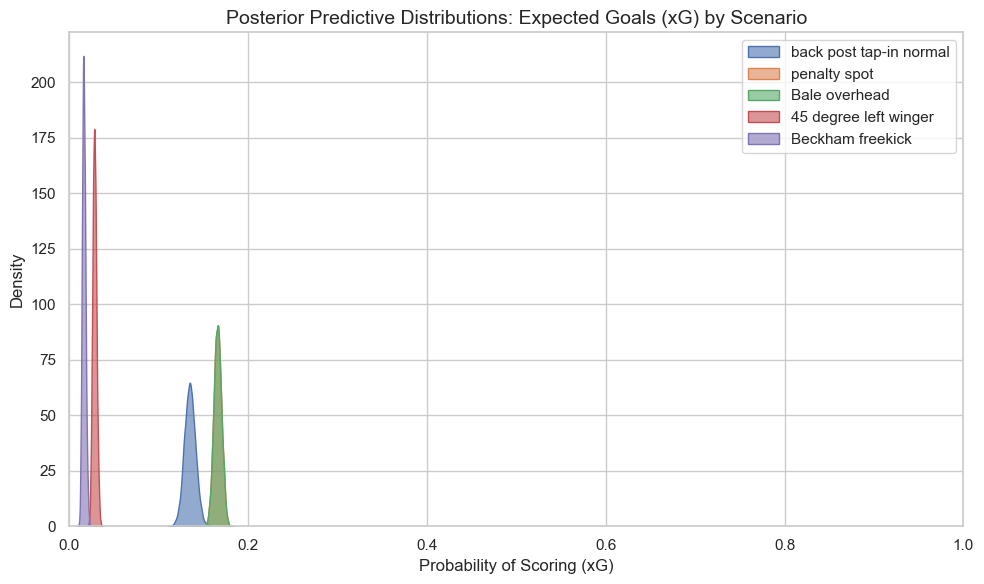

In [ ]:
prob_samples = post_pred.predictions['p'].stack(sample=("chain", "draw"))

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

scenario_names = [
    "back post tap-in normal", "penalty spot", "Bale overhead", "45 degree left winger", "Beckham freekick"
]

for i, name in enumerate(scenario_names):
    sns.kdeplot(prob_samples[i].values, label=name, fill=True, alpha=0.6, ax=ax)

ax.set_title("Posterior Predictive Distributions: Expected Goals (xG) by Scenario", fontsize=14)
ax.set_xlabel("Probability of Scoring (xG)")
ax.set_ylabel("Density")
ax.set_xlim(0, 1) 
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
with m2:
    pm.set_data({
            "dist_data": df_new_data['distance'].values, 
            "angle_data": df_new_data['angle'].values, 
            "technique_data": df_new_data['shot_with_technique'].values, 
            "y_data": [0,0,0,0,0] 
        })
    ppc = pm.sample_posterior_predictive(trace2, var_names=['p'], predictions=True, random_seed=100)

    post_pred = pm.sample_posterior_predictive(
        trace2, 
        var_names=['p'], 
        predictions=True, 
        random_seed=100
    )

Sampling: []


/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: []


/Users/shinsuke.adachi/miniconda3/envs/pymc_env/lib/python3.14/site-packages/rich/live.py:260: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [248]:
az.summary(ppc.predictions, hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p[0],0.133,0.007,0.119,0.145,0.0,0.0,4688.0,5211.0,1.0
p[1],0.163,0.005,0.154,0.174,0.0,0.0,6154.0,6243.0,1.0
p[2],0.172,0.008,0.155,0.187,0.0,0.0,6618.0,6347.0,1.0
p[3],0.028,0.002,0.023,0.032,0.0,0.0,3869.0,4684.0,1.0
p[4],0.016,0.002,0.012,0.020,0.0,0.0,3557.0,4255.0,1.0


In [249]:
print(az.summary(ppc.predictions, hdi_prob=0.95).to_latex(escape=True, float_format="%.3f"))

\begin{tabular}{lrrrrrrrrr}
\toprule
 & mean & sd & hdi\_2.5\% & hdi\_97.5\% & mcse\_mean & mcse\_sd & ess\_bulk & ess\_tail & r\_hat \\
\midrule
p[0] & 0.133 & 0.007 & 0.119 & 0.145 & 0.000 & 0.000 & 4688.000 & 5211.000 & 1.000 \\
p[1] & 0.163 & 0.005 & 0.154 & 0.174 & 0.000 & 0.000 & 6154.000 & 6243.000 & 1.000 \\
p[2] & 0.172 & 0.008 & 0.155 & 0.187 & 0.000 & 0.000 & 6618.000 & 6347.000 & 1.000 \\
p[3] & 0.028 & 0.002 & 0.023 & 0.032 & 0.000 & 0.000 & 3869.000 & 4684.000 & 1.000 \\
p[4] & 0.016 & 0.002 & 0.012 & 0.020 & 0.000 & 0.000 & 3557.000 & 4255.000 & 1.000 \\
\bottomrule
\end{tabular}



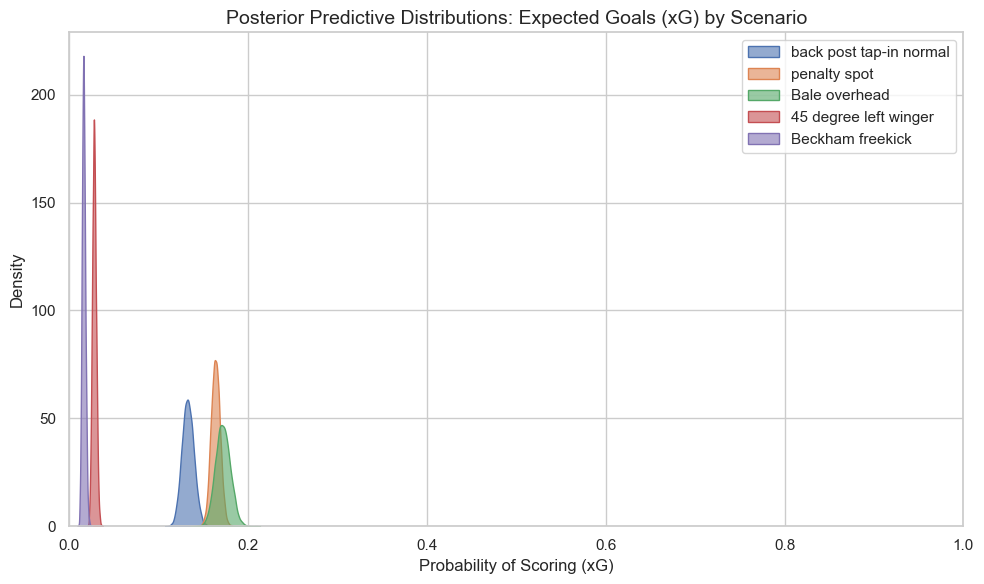

In [ ]:
prob_samples = post_pred.predictions['p'].stack(sample=("chain", "draw"))

fig, ax = plt.subplots(figsize=(10, 6))
sns.set_theme(style="whitegrid")

scenario_names = [
    "back post tap-in normal", "penalty spot", "Bale overhead", "45 degree left winger", "Beckham freekick"
]

for i, name in enumerate(scenario_names):
    sns.kdeplot(prob_samples[i].values, label=name, fill=True, alpha=0.6, ax=ax)

ax.set_title("Posterior Predictive Distributions: Expected Goals (xG) by Scenario", fontsize=14)
ax.set_xlabel("Probability of Scoring (xG)")
ax.set_ylabel("Density")
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()